# Task 2: EfficientNet-B0 for 60x80 Images

This notebook loads Notebook 1's prepared arrays and trains an EfficientNet-B0 variant that preserves a 5x4 final feature map for 60x80 images. Its editable hyperparameters start from the unweighted reference checkpoint's recorded values. Shared neural-network
augmentation, batching, checkpointing, recovery, and evaluation live in `src/task2_utils.py`.


## How to Run

Run `01_task2_setup.ipynb` first. Change the settings below if needed, then run this notebook.
It does not rerun setup or another model.


## 1. Setup


In [1]:
%matplotlib inline
from IPython.display import display


In [2]:
from pathlib import Path
import sys

REPO_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                  if (p / "pyproject.toml").exists()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Could not find the repository root containing pyproject.toml")
sys.path.insert(0, str(REPO_ROOT))

from src.task2_utils import (
    NeuralTrainer, build_task2_neural_model, ensure_task2_directories,
    model_checkpoint_path, neural_training_config, prepared_namespace, result_frame,
)
ensure_task2_directories()


### 1.1 Training configuration


In [3]:
QUICK_RUN = False
RANDOM_STATE = 42
RESUME = False
# Require a supported GPU for full training; CPU fallback is intentionally disabled.
ALLOW_CPU = False

# Editable hyperparameters copied from model_efficientnet_b0_reference_unweighted.pt.
# Change these values here for future tuning; training does not read the reference file.
HYPERPARAMETERS = {
    "epochs": 40,
    "warmup_epochs": 3,
    "batch_size": 64,
    "patience": 7,
    "learning_rate": 4e-4,
    "weight_decay": 6e-4,
    "label_smoothing": 0.08,
    # 0.0 preserves the unweighted reference recipe.
    "class_weight_power": 0.0,
    "flip_probability": 0.5,
    "rotation_degrees": 10.0,
    "translate_fraction": 0.08,
    "jitter_strength": 0.10,
}
CLASSIFIER_DROPOUT = 0.20

TRAINING_CONFIG = neural_training_config(
    quick_run=QUICK_RUN, random_state=RANDOM_STATE, resume=RESUME, allow_cpu=ALLOW_CPU,
)
TRAINING_CONFIG.update(HYPERPARAMETERS)
MODEL_CONFIG = {"architecture": "efficientnet_b0_small_input", **{
    key: value for key, value in TRAINING_CONFIG.items()
    if key not in {"resume", "allow_cpu", "keep_epoch_checkpoints"}
}, "classifier_dropout": CLASSIFIER_DROPOUT,
    "base_architecture": "efficientnet_b0",
    "spatial_change": "stage6_stride_1",
    "reference_recipe": "model_efficientnet_b0_reference_unweighted.pt",
}

## 2. Load Prepared Data and Shared Training Pipeline


In [4]:
data = prepared_namespace()
assert data.config.get("quick_run") == QUICK_RUN, (
    "QUICK_RUN does not match Notebook 1's prepared cache. "
    "Set the same value in both notebooks and rerun Notebook 1 if needed."
)
assert data.x_train.shape[1:] == (80, 60, 3), (
    f"Expected prepared 80x60 RGB images, got {data.x_train.shape[1:]}"
)
assert data.x_val.shape[1:] == (80, 60, 3), (
    f"Expected prepared 80x60 RGB images, got {data.x_val.shape[1:]}"
)
trainer = NeuralTrainer(data, TRAINING_CONFIG)
print(f"Loaded {len(data.train_frame):,} train and {len(data.validation_frame):,} validation rows")
print(f"Training batches per epoch: {len(trainer.train_loader)}")


Apple Metal GPU detected; using the PyTorch MPS backend.
Device: mps | mixed precision: False | run fingerprint: 5f507c7bb57f
Loaded 30,260 train and 7,566 validation rows
Training batches per epoch: 473


## 3. Train EfficientNet-B0


[EfficientNet-B0 Small Input] starting epoch 1/40 (473 train + 15 validation batches)
[EfficientNet-B0 Small Input] finished epoch 1/40 | train loss 1.1666 | val loss 1.1031 | train accuracy 0.4904 | val accuracy 0.5159 | macro-F1 0.2754 | best 0.2754 (epoch 1) | lr 2.67e-04 | 97s
[EfficientNet-B0 Small Input] starting epoch 2/40 (473 train + 15 validation batches)
[EfficientNet-B0 Small Input] finished epoch 2/40 | train loss 1.0766 | val loss 1.0139 | train accuracy 0.5418 | val accuracy 0.5904 | macro-F1 0.5216 | best 0.5216 (epoch 2) | lr 4.00e-04 | 125s
[EfficientNet-B0 Small Input] starting epoch 3/40 (473 train + 15 validation batches)
[EfficientNet-B0 Small Input] finished epoch 3/40 | train loss 1.0086 | val loss 0.9450 | train accuracy 0.5858 | val accuracy 0.6299 | macro-F1 0.5923 | best 0.5923 (epoch 3) | lr 4.00e-04 | 127s
[EfficientNet-B0 Small Input] starting epoch 4/40 (473 train + 15 validation batches)
[EfficientNet-B0 Small Input] finished epoch 4/40 | train loss 0.9

,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-2 accuracy
0,EfficientNet-B0 Small Input,0.751123,0.74544,0.710244,0.748788,0.942109


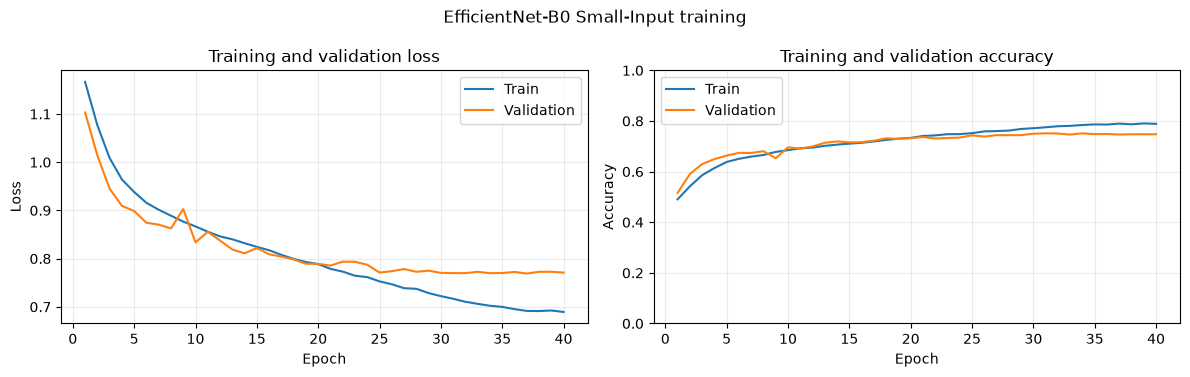

In [5]:
def build_model():
    return build_task2_neural_model(MODEL_CONFIG, data.n_classes)

efficientnet, history, logits = trainer.train_or_restore(
    "efficientnet_b0", build_model,
    "EfficientNet-B0 Small Input", MODEL_CONFIG
)
predictions = logits.argmax(axis=1)
display(result_frame(data.y_val, predictions, logits, "EfficientNet-B0 Small Input"))
trainer.plot_history(history, "EfficientNet-B0 Small-Input training")


## 4. Export EfficientNet-B0 Results


In [6]:
print("Completed checkpoint:", model_checkpoint_path("efficientnet_b0"))
print("Run fingerprint:", data.fingerprint)


Completed checkpoint: /Users/s4030327/Machine-Learning-Assignment-2/models/task2/checkpoints/model_efficientnet_b0.pt
Run fingerprint: 5f507c7bb57f
